# 04 — EDA univariado: distribuciones y outliers

**Objetivo especifico que responde:** contenido analitico base de OE-04 (`InformesRev/AnteproyectoAndres.md`, RF-05: "visualizaciones interactivas (distribuciones, box plots, segmentaciones)"), aunque el tablero interactivo en si se construya en una fase posterior — el contenido estadistico y grafico debe quedar listo aqui.

**Insumo:** `analitica-descriptiva-andres/data/indicadores_restriccion_hierro.parquet` (notebook 03).

**Criterio de reporte:** para variables con distribucion asimetrica se reporta mediana y rango intercuartilico (RIC), no solo media y desviacion estandar, siguiendo el estandar de rigor exigido en `PROMPT_EDA_EXTENSO_OE02_OE03.md` (seccion 4, notebook 04).

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

REPO = Path(".").resolve().parents[1] if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATA_DIR = REPO / "analitica-descriptiva-andres" / "data"
FIG_DIR = REPO / "analitica-descriptiva-andres" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_DIR / "indicadores_restriccion_hierro.parquet")
print("Indicadores cargados:", df.shape)


Indicadores cargados: (19194, 28)


In [2]:
def resumen_robusto(serie, nombre):
    s = serie.dropna()
    print(f"--- {nombre} (N={len(s)}) ---")
    print(f"Media: {s.mean():.2f} | Desv. estandar: {s.std():.2f}")
    print(f"Mediana: {s.median():.2f} | RIC (P25-P75): {s.quantile(.25):.2f} a {s.quantile(.75):.2f}")
    print(f"Min: {s.min():.2f} | P1: {s.quantile(.01):.2f} | P99: {s.quantile(.99):.2f} | Max: {s.max():.2f}")
    print()

for col, nombre in [
    ('desviacion_tiempo_dias', 'Desviacion de tiempo (dias)'),
    ('desviacion_costo_pct', 'Desviacion de costo (%)'),
    ('valor_del_contrato', 'Valor del contrato (COP)'),
    ('plazo_pactado_dias', 'Plazo pactado (dias)'),
    ('plazo_real_dias', 'Plazo real de ejecucion (dias)'),
]:
    resumen_robusto(df[col], nombre)


--- Desviacion de tiempo (dias) (N=16326) ---
Media: 35.69 | Desv. estandar: 463.57
Mediana: 2.00 | RIC (P25-P75): -1.00 a 60.00
Min: -30072.00 | P1: -90.00 | P99: 627.75 | Max: 1721.00

--- Desviacion de costo (%) (N=8681) ---
Media: -7.93 | Desv. estandar: 18.63
Mediana: 0.00 | RIC (P25-P75): -2.88 a 0.00
Min: -99.86 | P1: -86.17 | P99: 0.00 | Max: 66.29

--- Valor del contrato (COP) (N=19194) ---
Media: 2618324485.27 | Desv. estandar: 16364780957.38
Mediana: 268794495.00 | RIC (P25-P75): 77729993.25 a 1009880000.25
Min: 1.00 | P1: 6000000.00 | P99: 39935733000.93 | Max: 610461362068.00

--- Plazo pactado (dias) (N=16326) ---
Media: 182.21 | Desv. estandar: 503.05
Mediana: 115.00 | RIC (P25-P75): 60.00 a 229.75
Min: 1.00 | P1: 8.00 | P99: 969.75 | Max: 33420.00

--- Plazo real de ejecucion (dias) (N=19194) ---
Media: 231.43 | Desv. estandar: 279.93
Mediana: 136.00 | RIC (P25-P75): 61.00 a 303.00
Min: 0.00 | P1: 4.00 | P99: 1369.00 | Max: 7305.00



## 1. Distribuciones y outliers — desviacion de tiempo

Dado que el minimo y el maximo son ordenes de magnitud mas extremos que el RIC (heredados de inconsistencias ya documentadas del dato fuente SECOP: duraciones o fechas absurdas), se aplica **winsorizacion en los percentiles 1 y 99 unicamente para la visualizacion** (no se modifica el dato guardado en el notebook 03). Este es un criterio estadistico estandar de tratamiento de outliers, aplicado aqui de forma independiente, no copiado de ningun notebook del companero.

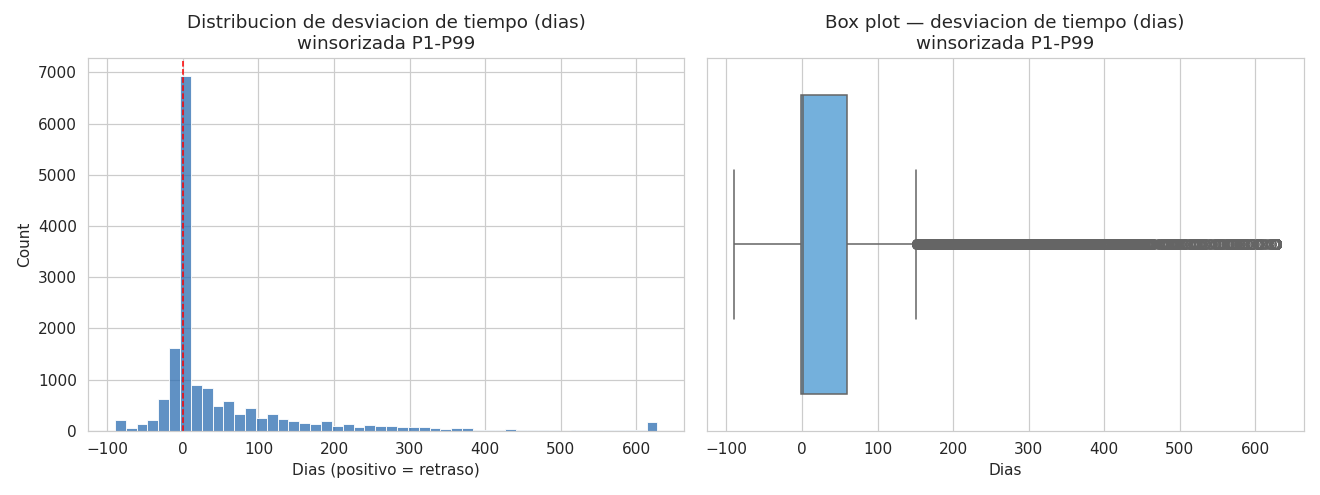

In [3]:
def winsorizar(serie, p_bajo=0.01, p_alto=0.99):
    s = serie.dropna()
    lo, hi = s.quantile(p_bajo), s.quantile(p_alto)
    return s.clip(lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
wins_tiempo = winsorizar(df['desviacion_tiempo_dias'])
sns.histplot(wins_tiempo, bins=50, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Distribucion de desviacion de tiempo (dias)\nwinsorizada P1-P99")
axes[0].set_xlabel("Dias (positivo = retraso)")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

sns.boxplot(x=wins_tiempo, ax=axes[1], color="#63b3ed")
axes[1].set_title("Box plot — desviacion de tiempo (dias)\nwinsorizada P1-P99")
axes[1].set_xlabel("Dias")
plt.tight_layout()
ruta = FIG_DIR / "04_desviacion_tiempo.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 2. Distribuciones y outliers — desviacion de costo (%)

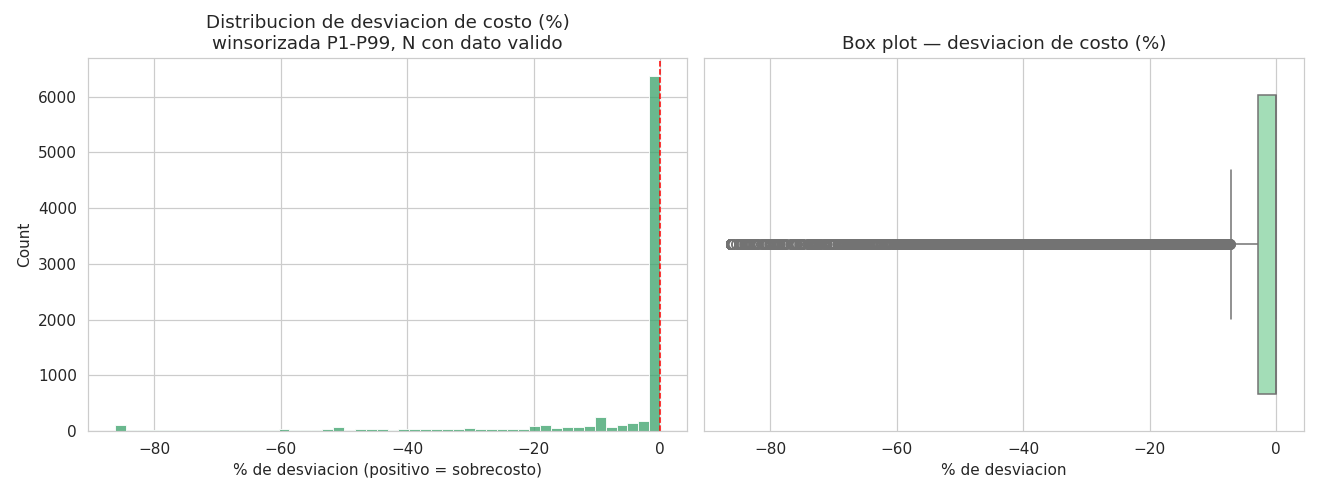

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
wins_costo = winsorizar(df['desviacion_costo_pct'])
sns.histplot(wins_costo, bins=50, ax=axes[0], color="#38a169")
axes[0].set_title("Distribucion de desviacion de costo (%)\nwinsorizada P1-P99, N con dato valido")
axes[0].set_xlabel("% de desviacion (positivo = sobrecosto)")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

sns.boxplot(x=wins_costo, ax=axes[1], color="#9ae6b4")
axes[1].set_title("Box plot — desviacion de costo (%)")
axes[1].set_xlabel("% de desviacion")
plt.tight_layout()
ruta = FIG_DIR / "04_desviacion_costo.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 3. Valor del contrato (escala logaritmica) y plazos

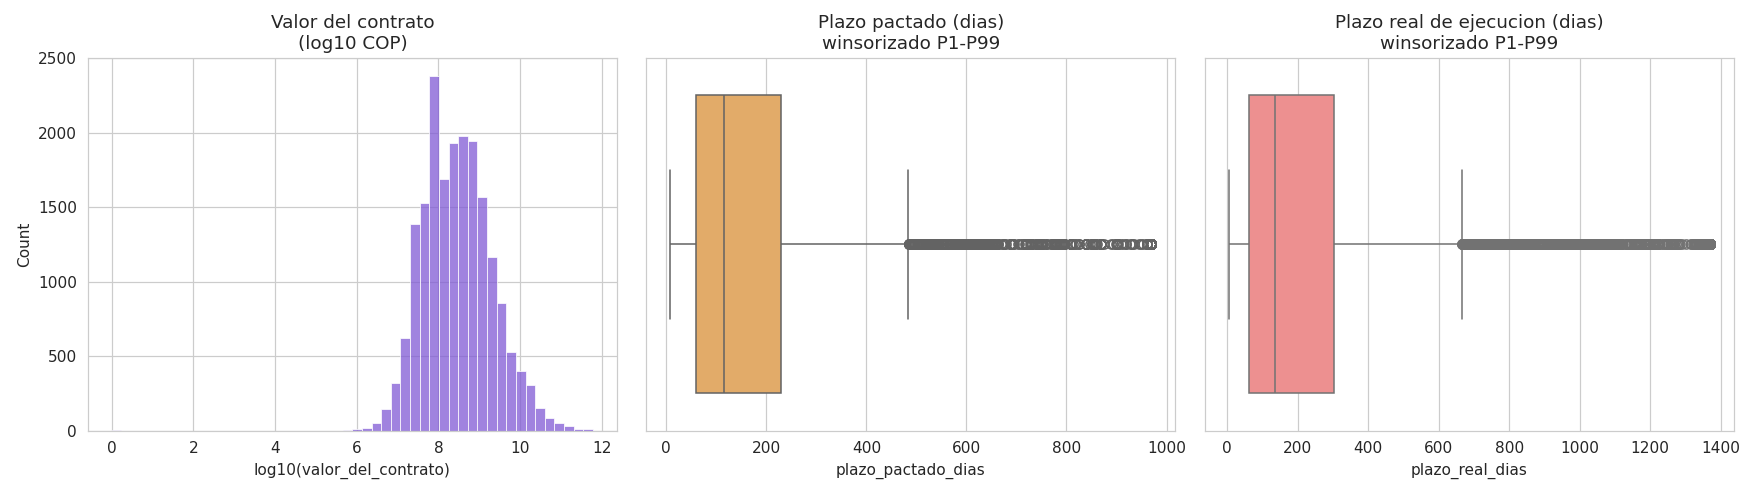

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

valor_positivo = df.loc[df['valor_del_contrato'] > 0, 'valor_del_contrato']
sns.histplot(np.log10(valor_positivo), bins=50, ax=axes[0], color="#805ad5")
axes[0].set_title("Valor del contrato\n(log10 COP)")
axes[0].set_xlabel("log10(valor_del_contrato)")

sns.boxplot(x=winsorizar(df['plazo_pactado_dias']), ax=axes[1], color="#f6ad55")
axes[1].set_title("Plazo pactado (dias)\nwinsorizado P1-P99")

sns.boxplot(x=winsorizar(df['plazo_real_dias']), ax=axes[2], color="#fc8181")
axes[2].set_title("Plazo real de ejecucion (dias)\nwinsorizado P1-P99")

plt.tight_layout()
ruta = FIG_DIR / "04_valor_y_plazos.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 4. Variables independientes clave (categoricas)

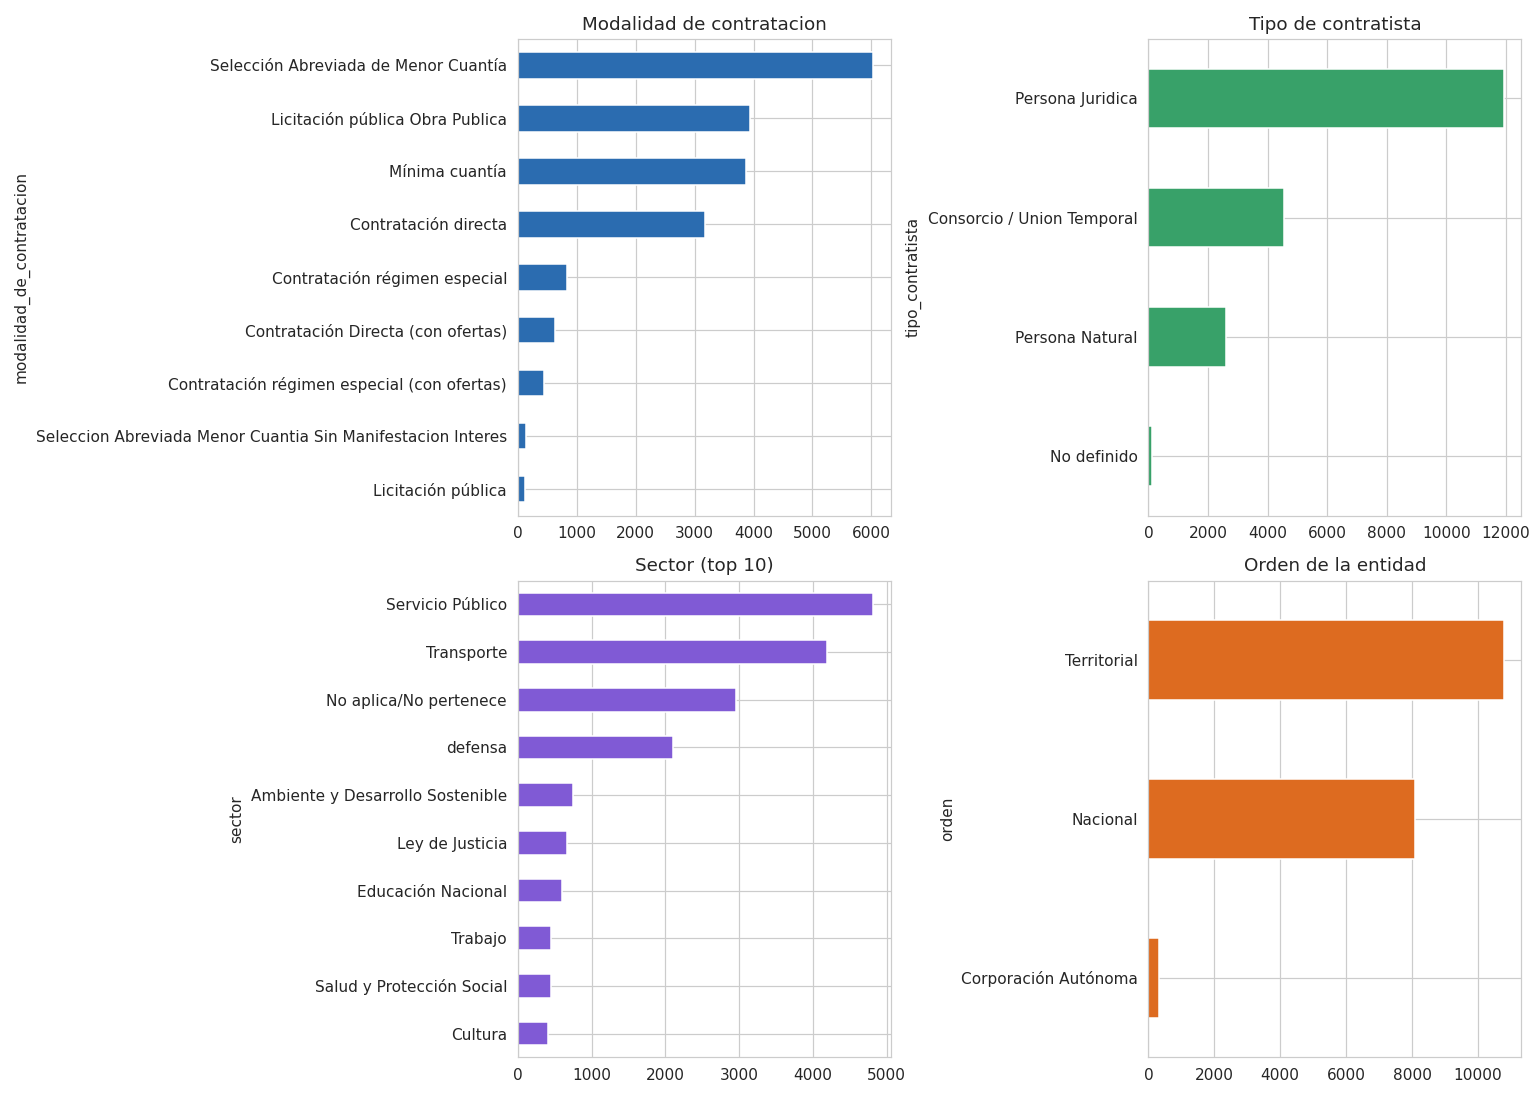

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['modalidad_de_contratacion'].value_counts().plot(kind='barh', ax=axes[0,0], color="#2b6cb0")
axes[0,0].set_title("Modalidad de contratacion")
axes[0,0].invert_yaxis()

df['tipo_contratista'].value_counts().plot(kind='barh', ax=axes[0,1], color="#38a169")
axes[0,1].set_title("Tipo de contratista")
axes[0,1].invert_yaxis()

df['sector'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color="#805ad5")
axes[1,0].set_title("Sector (top 10)")
axes[1,0].invert_yaxis()

df['orden'].value_counts().plot(kind='barh', ax=axes[1,1], color="#dd6b20")
axes[1,1].set_title("Orden de la entidad")
axes[1,1].invert_yaxis()

plt.tight_layout()
ruta = FIG_DIR / "04_variables_categoricas.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 5. Indice de cumplimiento de alcance (distribucion categorica dependiente)

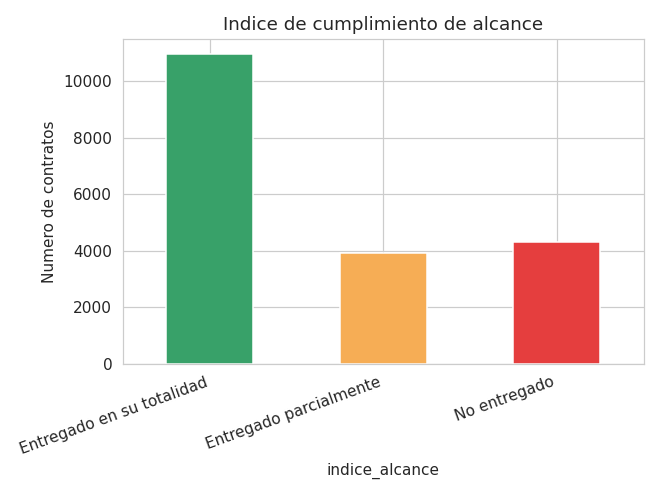

indice_alcance
Entregado en su totalidad    57.1
Entregado parcialmente       20.4
No entregado                 22.5
Name: count, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
orden_cats = ['Entregado en su totalidad', 'Entregado parcialmente', 'No entregado']
conteo = df['indice_alcance'].value_counts().reindex(orden_cats)
conteo.plot(kind='bar', ax=ax, color=["#38a169", "#f6ad55", "#e53e3e"])
ax.set_title("Indice de cumplimiento de alcance")
ax.set_ylabel("Numero de contratos")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
ruta = FIG_DIR / "04_indice_alcance.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))

print((conteo / len(df) * 100).round(1))


## 6. Sintesis de hallazgos de este notebook

- La desviacion de tiempo y la desviacion de costo presentan distribuciones fuertemente asimetricas con outliers extremos heredados del dato fuente; se reportan estadisticos robustos (mediana, RIC) ademas de media/desviacion estandar, y se aplico winsorizacion P1-P99 exclusivamente para fines de visualizacion.
- La modalidad de contratacion mas frecuente en la muestra analitica es "Seleccion Abreviada de Menor Cuantia", seguida de contratacion directa y minima cuantia; la licitacion publica (mecanismo de mayor competencia segun H1) es minoritaria.
- Los consorcios/uniones temporales representan una proporcion relevante del total de contratistas, lo cual sustenta la viabilidad de contrastar la hipotesis H2 en el notebook 07.
- El 57.1% de los contratos de la muestra analitica se clasifican como "Entregado en su totalidad", 22.5% "No entregado" (terminacion anticipada) y 20.4% "Entregado parcialmente" (suspension o cesion) — ver notebook 03 para el detalle exacto.
- Todas las figuras se guardaron en `analitica-descriptiva-andres/figuras/` para su reutilizacion directa en el documento de tesis.